# Testing the EM-EDX classs and basic usage of the methods
- An EM-EDX pair are saved in the EM-EDX class, along with the corresponding xray energies from the EMD file.
- Preprocessing methods are tracked in the class instance.

In [22]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils_EDX import *
import numpy as np
import hyperspy.api as hs
import os
import matplotlib.pyplot as plt
import copy
from importlib import reload
from EDX import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Define an EM-EDX instance

In [29]:
# load data
file_path = "../data/EMD/EDXdataset.emd"
EDX, haadf, xray_energies = load_EDX(file_path, first_frame=None, last_frame=50,sum_frames=True)

WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)


In [3]:
# define an instance and apply preprocessing (copy_instance defaults to false)
tile = EM_EDX(haadf, EDX, xray_energies)
tile = tile.apply("crop", parameters = {"crop_idx": (0,1000,0,1000,0,1000)}, notes='first operation')

# summary
tile.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(0, 1000, 0, 1000, 0, 1000)","(1000, 1000)","(1000, 1000, 1000)",first operation


#### copy_instance set to True to define a new EM-EDX instnce (while preserving the memory of the old one)

In [4]:
tile2 = tile.apply("crop", parameters={"crop_idx": (slice(0,100),slice(0,200),slice(0,1000,10))},copy_instance=True)
tile2.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(0, 1000, 0, 1000, 0, 1000)","(1000, 1000)","(1000, 1000, 1000)",first operation
1,crop,"crop_idx=(slice(0, 100, None), slice(0, 200, N...","(100, 200)","(100, 200, 100)",None


#### Binning usage

In [5]:
tile3 = tile.apply("binning", parameters={"dim": (500,500,250)})
tile3.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(0, 1000, 0, 1000, 0, 1000)","(1000, 1000)","(1000, 1000, 1000)",first operation
1,binning,"dim=(500, 500, 250)","(500, 500)","(500, 500, 250)",None


## Multiple preprocessing steps (à la the identify paper github.com/amjams/HyperspectralEDX)

In [30]:
# load show dimensions
tile = EM_EDX(haadf, EDX, xray_energies)
print(tile.EDX_dim)

(2048, 2048, 4096)


In [ ]:
# preprocess
tile.apply("crop", parameters={"crop_idx": (slice(None),slice(None),slice(96,4096))})
tile.apply("binning", parameters={"dim": (1024,1024,250)})
tile.apply("MeanFilterEDX", parameters={"kernel_size": 3})
tile.summary()

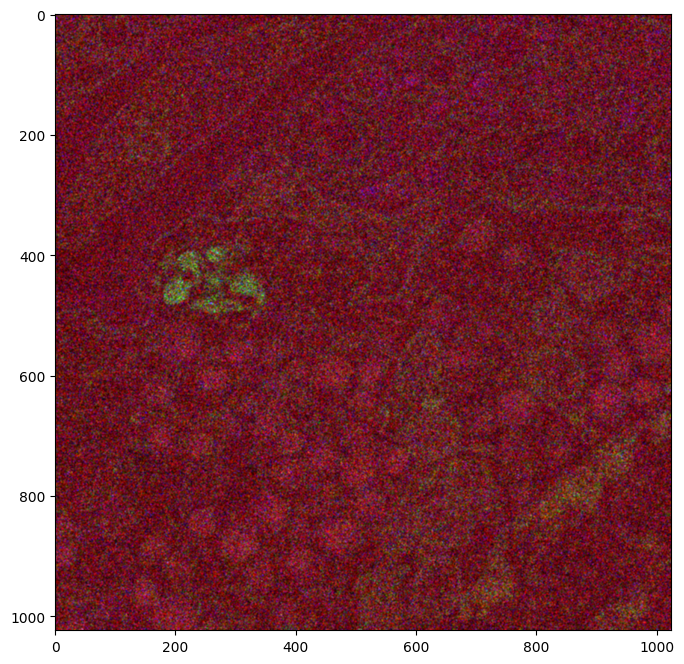

In [28]:
# visualize the haadf and a false-color of NPS maps
nps = tile.FalseColor()
f, ax = plt.subplots(figsize=(8,8))
ax.imshow(nps)
plt.show()
